# 📊 Customer Churn Prediction

## 🧠 Problem Statement
Customer churn is a critical problem for businesses, as losing customers directly impacts revenue. The objective of this project is to analyze customer data and build a machine learning model to predict whether a customer will churn or not.

## 🎯 Objectives
- Perform Exploratory Data Analysis (EDA)
- Identify key factors influencing churn
- Clean and preprocess the data
- Build classification models
- Evaluate and compare model performance

## 📊 Dataset
The dataset contains customer information such as demographics, account details, and service usage.

---

## 📥 Data Loading

In this step, we load the dataset into the notebook and examine its initial structure.

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np

# Loading dataset
df = pd.read_csv('/content/Customer Churn.csv')

# Previewing data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 🔍 Data Understanding

In this step, we explore the dataset structure, data types, and statistical summary to gain initial insights.

In [ ]:
# Shape of dataset
df.shape

(7043, 21)

In [ ]:
# Column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 📌 Initial Observations

- The dataset contains 7043 rows and 21 columns  
- Data types include:
  - Numerical: tenure, MonthlyCharges  
  - Categorical: gender, Partner, Dependents, etc.  
  - Object type: customerID, TotalCharges  
- Missing values are not explicitly present, but there may be hidden missing values in 'TotalCharges'  
- The 'TotalCharges' column has incorrect data type (object instead of numeric) and needs conversion  
- The target variable is 'Churn', which indicates whether a customer has left or not  

In [ ]:
(df['TotalCharges'] == " ").sum()

np.int64(11)

In [ ]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [ ]:
df.dropna(inplace = True)

## 📈 Exploratory Data Analysis (EDA)

In this step, we analyze customer behavior and identify patterns that influence churn.

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


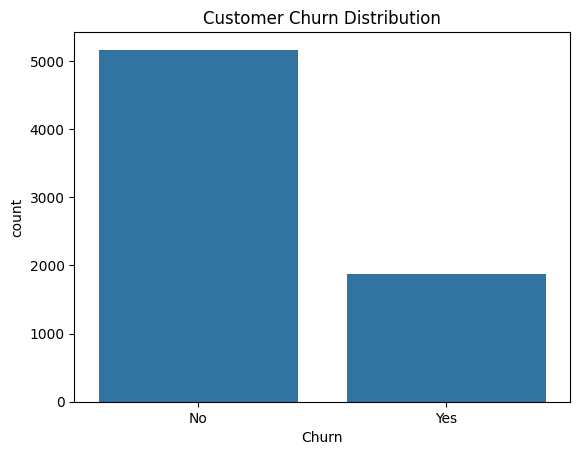

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()


### 📌 Insight

- Majority of customers have NOT churned (Churn = No)  
- Minority of customers have churned (Churn = Yes)  
- The dataset is imbalanced  

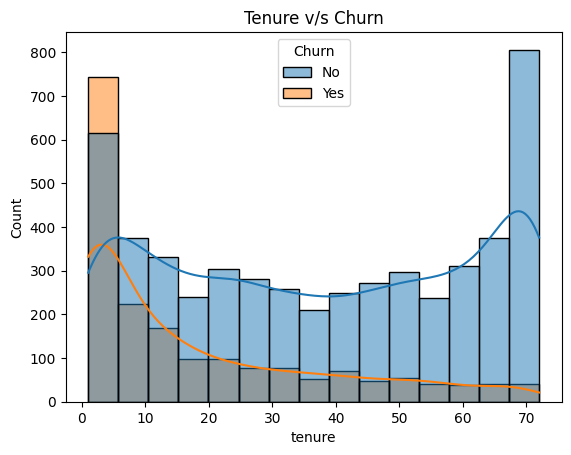

In [ ]:
sns.histplot(data = df, x ='tenure', hue = 'Churn', kde = True)
plt.title('Tenure v/s Churn')
plt.show()

### 📌 Insight

- Customers with low tenure are more likely to churn, indicating that new customers are at higher risk of leaving  
- Customers with longer tenure are less likely to churn, showing higher loyalty and retention over time  

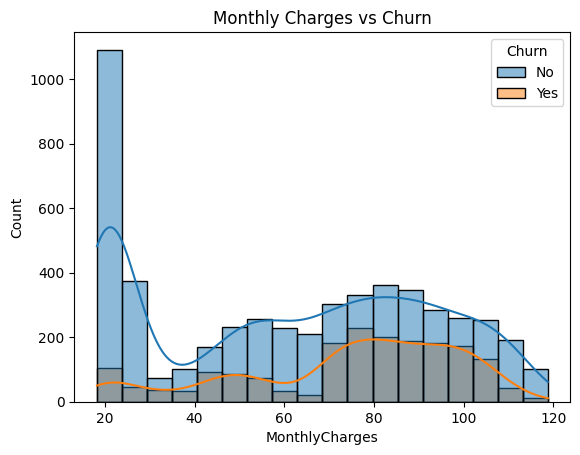

In [ ]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)
plt.title('Monthly Charges vs Churn')
plt.show()

### 📌 Insight

- Customers with higher monthly charges are more likely to churn, indicating that higher pricing may contribute to customer dissatisfaction or perceived lack of value  
- Customers with lower monthly charges tend to have lower churn rates, suggesting better affordability and retention  

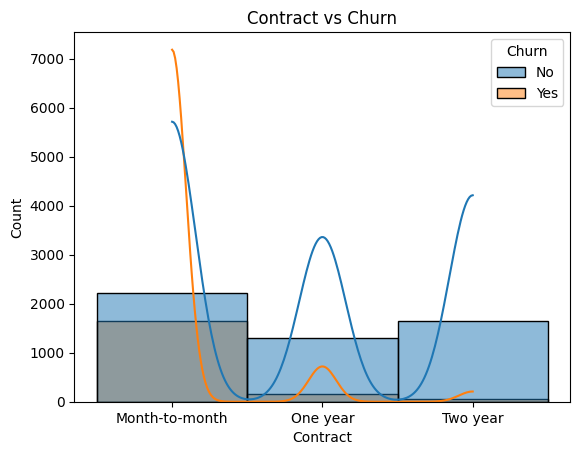

In [ ]:
sns.histplot(data=df, x='Contract', hue='Churn', kde=True)
plt.title('Contract vs Churn')
plt.show()

### 📌 Insight

- Customers with month-to-month contracts are more likely to churn, likely due to lower commitment and flexibility to switch services  
- Customers with one-year and two-year contracts have significantly lower churn rates, indicating higher commitment and stronger customer retention  

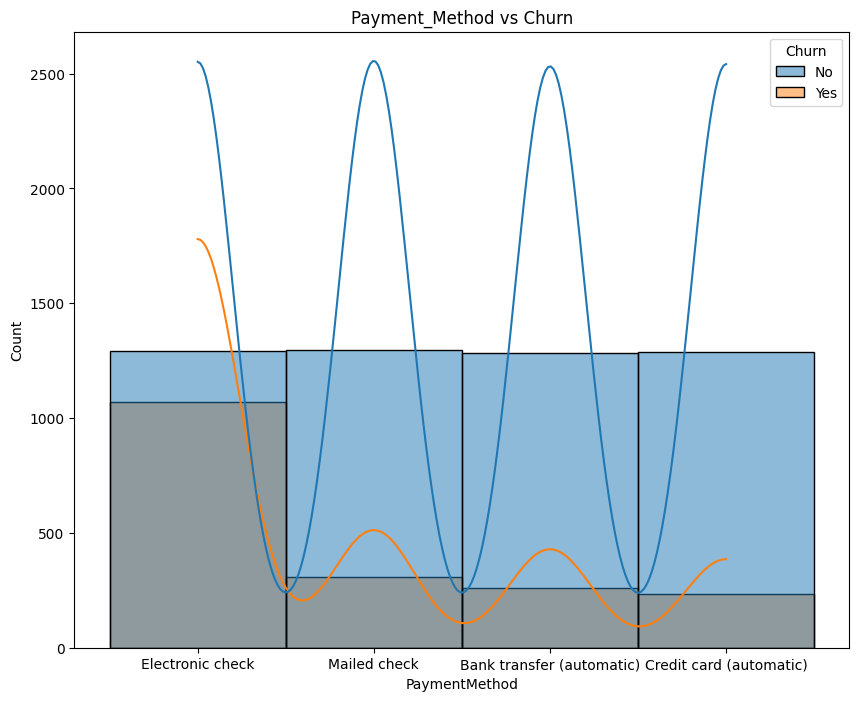

In [ ]:
plt.figure(figsize = (10,8))
sns.histplot(data=df, x='PaymentMethod', hue='Churn', kde=True)
plt.title('Payment_Method vs Churn')
plt.show()

### 📌 Insight

- Customers using automatic payment methods such as bank transfer and credit card have lower churn rates, indicating that seamless and automated payment processes improve customer retention  
- Customers using mailed check show moderate churn behavior  
- Customers using electronic check exhibit the highest churn rates, possibly due to manual effort, inconvenience, or delays in the payment process  

## ⚙️ Data Preprocessing

In this step, we convert categorical variables into numerical format and prepare the dataset for machine learning models.

### We can drop unnecessary columns

In [ ]:
df.drop('customerID', axis=1, inplace=True)

### Encoding Target Variable

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

### Encoding independent Variables

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.dtypes

,0
SeniorCitizen,int64
tenure,int64
MonthlyCharges,float64
TotalCharges,float64
Churn,int64
gender_Male,bool
Partner_Yes,bool
Dependents_Yes,bool
PhoneService_Yes,bool
MultipleLines_No phone service,bool


### Splitting data into dependent and independent variables

In [ ]:
X = df.drop(['Churn'], axis = 1)
y = df['Churn']

## 🔀 Train-Test Split

In this step, we split the dataset into training and testing sets to evaluate model performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 73)

print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


## 🤖 Model Building: Logistic Regression

In this step, we build our first machine learning model using Logistic Regression. This model is used for binary classification problems and will help us predict whether a customer will churn or not.

We train the model on the training dataset and evaluate its performance on unseen test data.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

LR = LogisticRegression()

In [ ]:
LR.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_predict = LR.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_predict)
print(accuracy*100)

80.81023454157783


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_predict))

[[942  94]
 [176 195]]


In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.53      0.59       371

    accuracy                           0.81      1407
   macro avg       0.76      0.72      0.73      1407
weighted avg       0.80      0.81      0.80      1407



### 📌 Model Evaluation Insight

- The Logistic Regression model achieves an accuracy of around 81%, but accuracy alone is not sufficient due to class imbalance  
- The model performs well in predicting non-churn customers with a high recall of 91%  
- However, it struggles to identify churn customers, with a recall of only 53%  
- This indicates that nearly half of the actual churn cases are missed, which is a critical limitation from a business perspective  
- Therefore, improving recall for churn prediction should be a priority in further model development  

## 🌲 Model Building: Random Forest

In this step, we build a Random Forest Classifier, an ensemble learning method that combines multiple decision trees to improve prediction accuracy and handle complex patterns in the data.

Random Forest is expected to perform better than Logistic Regression, especially in capturing non-linear relationships.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[931 105]
 [186 185]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1036
           1       0.64      0.50      0.56       371

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf * 100)

Accuracy: 79.317697228145


### 📌 Model Comparison Insight

- The Random Forest model did not outperform Logistic Regression in this case  
- Accuracy decreased slightly from 81% to 79%  
- Recall for churn prediction also dropped from 53% to 50%  
- This indicates that Random Forest, without tuning, is not effectively capturing churn patterns  
- Logistic Regression performed slightly better for this dataset  

## ⚖️ Handling Class Imbalance using SMOTE

In this step, we apply SMOTE (Synthetic Minority Oversampling Technique) to balance the dataset by generating synthetic samples for the minority class (churn).

This helps improve the model's ability to detect churn customers.

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=73)

In [ ]:
X_train_smote,y_train_smote = smote.fit_resample(X_train,y_train)

In [ ]:
lr_smote = LogisticRegression(max_iter = 1001)

lr_smote.fit(X_train_smote,y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1001)

In [ ]:
y_predict_smote = lr_smote.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_predict_smote))

[[867 169]
 [142 229]]


In [ ]:
print(classification_report(y_test, y_predict_smote))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1036
           1       0.58      0.62      0.60       371

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [ ]:
accuracy_smote = accuracy_score(y_test,y_predict_smote)*100
accuracy_smote

77.89623312011372

### 📌 Model Improvement Insight (SMOTE)

- Applying SMOTE helped balance the dataset and improved the model's ability to detect churn customers  
- Recall for churn increased from 53% to 62%, indicating better identification of at-risk customers  
- Although accuracy decreased slightly, the improvement in recall makes the model more valuable from a business perspective  
- This demonstrates the importance of handling class imbalance in classification problems  

## 📊 Model Comparison

In this project, multiple models were applied and evaluated to predict customer churn.

- Logistic Regression achieved good overall accuracy and provided a strong baseline model  
- Random Forest did not significantly improve performance and showed slightly lower recall for churn prediction  
- Applying SMOTE improved the model’s ability to detect churn customers by increasing recall, although it introduced more false positives  

Overall, Logistic Regression with SMOTE provided the best balance between detecting churn and maintaining reasonable performance.

## 🧠 Conclusion

- The objective of this project was to predict customer churn using machine learning techniques  
- Exploratory Data Analysis revealed that factors such as tenure, monthly charges, contract type, and payment method significantly influence churn behavior  
- Logistic Regression served as a strong baseline model but struggled with identifying churn customers due to class imbalance  
- Random Forest did not outperform Logistic Regression in this case  
- Applying SMOTE improved recall and helped the model better identify at-risk customers  
- From a business perspective, improving recall is crucial to proactively retain customers and reduce revenue loss  

This project highlights the importance of handling class imbalance and selecting appropriate evaluation metrics in classification problems.

## 💼 Business Impact

By identifying customers likely to churn, businesses can take proactive actions such as targeted offers, improved services, or engagement strategies to improve customer retention.